In [41]:
import pandas as pd
df=pd.read_csv('Salary_Data.csv')
df.head()

,YearsExperience,Salary,bonus
0,1.1,39343,not deserved
1,1.3,46205,not deserved
2,1.5,37731,not deserved
3,2.0,43525,not deserved
4,2.2,39891,not deserved


In [42]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
 2   bonus            30 non-null     object 
dtypes: float64(1), int64(1), object(1)
memory usage: 852.0+ bytes


(30, 3)

In [43]:
df.isnull().sum()

YearsExperience    0
Salary             0
bonus              0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [44]:
df.describe().round()

,YearsExperience,Salary
count,30.0,30.0
mean,5.0,76003.0
std,3.0,27414.0
min,1.0,37731.0
25%,3.0,56721.0
50%,5.0,65237.0
75%,8.0,100545.0
max,10.0,122391.0


In [45]:
df['bonus']=[
    "deserved" if x >=3.5 else "not deserved"
    for x in df["YearsExperience"]
]
df

,YearsExperience,Salary,bonus
0,1.1,39343,not deserved
1,1.3,46205,not deserved
2,1.5,37731,not deserved
3,2.0,43525,not deserved
4,2.2,39891,not deserved
5,2.9,56642,not deserved
6,3.0,60150,not deserved
7,3.2,54445,not deserved
8,3.2,64445,not deserved
9,3.7,57189,deserved


In [48]:
df['ExperienceGroup']=[ "0-2 years" if x<=2 else "3-5 years" if 2<x<6 else "6+ years"
                        for x in df['YearsExperience']   
                      ]
df

,YearsExperience,Salary,bonus,ExperienceGroup
0,1.1,39343,not deserved,0-2 years
1,1.3,46205,not deserved,0-2 years
2,1.5,37731,not deserved,0-2 years
3,2.0,43525,not deserved,0-2 years
4,2.2,39891,not deserved,3-5 years
5,2.9,56642,not deserved,3-5 years
6,3.0,60150,not deserved,3-5 years
7,3.2,54445,not deserved,3-5 years
8,3.2,64445,not deserved,3-5 years
9,3.7,57189,deserved,3-5 years


In [95]:
x1 = group1['Salary'].mean()
x2=group2['Salary'].mean()
x3=group3['Salary'].mean()
print("group1 is : ",x1)
print("group2 is : ",x2)
print("group3 is : ",x3)

group1 is :  41701.0
group2 is :  61689.4
group3 is :  107995.0


In [104]:
print("big is ",max(x1,x2,x3))

big is  107995.0


Text(0, 0.5, 'Salary')

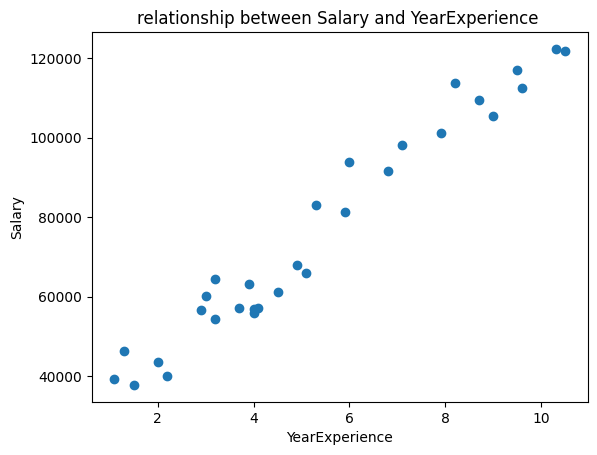

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.scatter(df['YearsExperience'],df['Salary'])
plt.title("relationship between Salary and YearExperience ")
plt.xlabel("YearExperience")
plt.ylabel("Salary")

Text(0, 0.5, 'Salary')

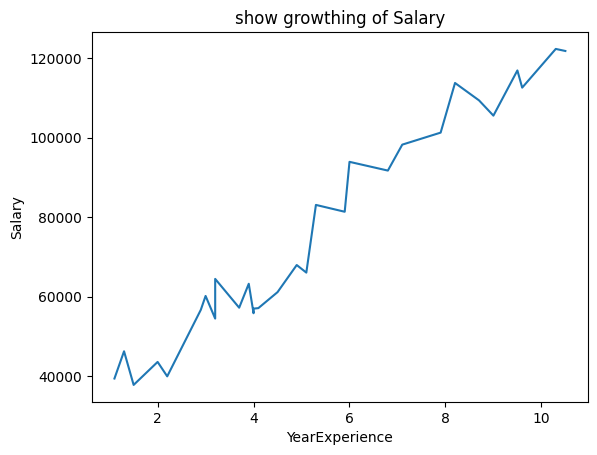

In [17]:
plt.plot(df['YearsExperience'],df['Salary'])
plt.title("show growthing of Salary")
plt.xlabel("YearExperience")
plt.ylabel("Salary")

Text(0.5, 0, 'Salary')

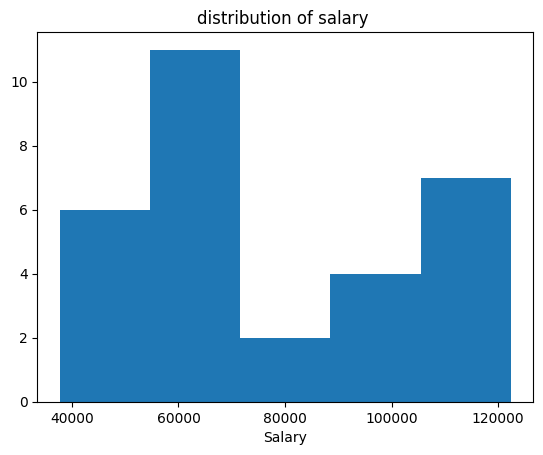

In [52]:
plt.hist(df["Salary"],bins=5)
plt.title("distribution of salary ")
plt.xlabel("Salary")

Text(0, 0.5, 'Salary')

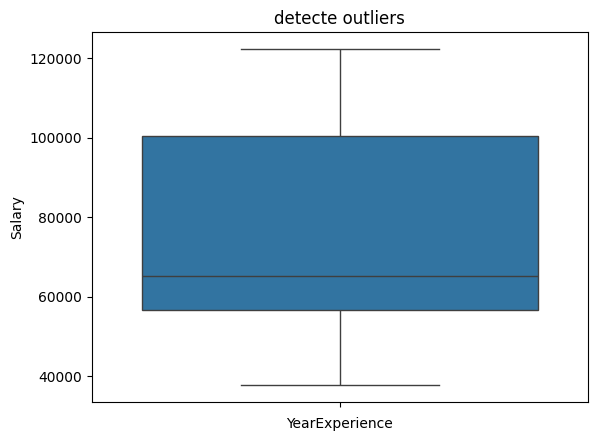

In [19]:
sns.boxplot(df["Salary"])
plt.title("detecte outliers")
plt.xlabel("YearExperience")
plt.ylabel("Salary")

In [58]:
df.to_csv(r'C:\Users\hp\Documents\ProjectsJupyter\Salary_Data.csv',index=False)

# Machine Learning

In [116]:
from sklearn import linear_model
model=linear_model.LinearRegression()
features=df[['YearsExperience']].to_numpy()
traget=df[['Salary']]

# Train model

In [117]:
model.fit(features,traget)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [93]:
model.coef_

array([[9449.96232146]])

In [94]:
model.intercept_

array([25792.20019867])

# Predict Salary

In [118]:
y_predict=model.predict([[10.5]])
y_predict.round()

array([[125017.]])

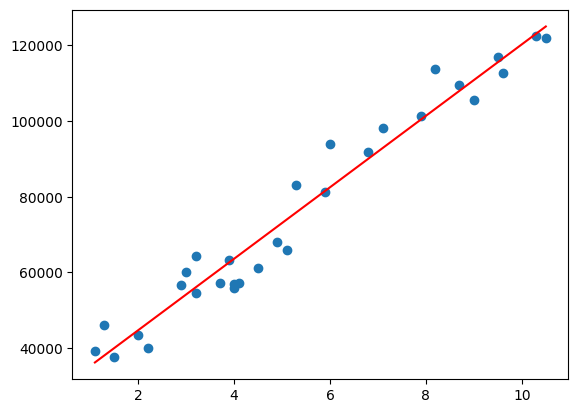

In [119]:
plt.scatter(features,traget)
plt.plot(features,model.predict(features),'r')

# Eavluation

In [126]:
model.score(features,traget)

0.9569566641435086